<a href="https://colab.research.google.com/github/Raijeku/quantum-eigengame/blob/main/EigenGame_theory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EigenGame theory

## Imports

In [ ]:
import autograd.numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm, sqrtm, eigh
import networkx as nx
from jax import grad, jacfwd, hessian
from jax.lax import stop_gradient
import jax.numpy as jnp
import numpy

## Functions

In [ ]:
from jax import vjp

def generate_matrix(eigenvalues):
  D = np.diag(eigenvalues)
  P = np.random.rand(D.shape[0], D.shape[0])
  norm = np.linalg.norm(P)
  P = P/norm
  np.fill_diagonal(P, 1)
  return np.dot(P, np.dot(D, np.linalg.inv(P))), P

# Variational functions
def Ry(theta):
  return jnp.array([[jnp.cos(theta), -jnp.sin(theta)],
                    [jnp.sin(theta), jnp.cos(theta)]])

def U3(theta_3):
  return jnp.array([[jnp.cos(theta_3[0]/2), -jnp.exp(1j*theta_3[2])*jnp.sin(theta_3[0]/2)],
                   [jnp.exp(1j*theta_3[1])*jnp.sin(theta_3[0]/2), jnp.exp(1j*(theta_3[1]+theta_3[2]))*jnp.cos(theta_3[0]/2)]])

def CX(theta):
    CX_gate = jnp.array([[1, 0, 0, 0],
                        [0, 1, 0, 0],
                        [0, 0, 0, 1],
                        [0, 0, 1, 0]])

    return CX_gate

def ansatz(theta, gate=Ry, two_qubit_gate=None):
  qubits, layers = theta.shape[:2]
  n = 2**qubits

  U = jnp.eye(n)
  for l in range(layers):
    U_l = gate(theta[0,l])
    for k in range(1, qubits):
      U_l = jnp.kron(U_l, gate(theta[k, l]))
    U = jnp.matmul(U, U_l)

    if two_qubit_gate is not None:
      for q in range(qubits - 1):
        U_two = jnp.kron(jnp.eye(2**q), two_qubit_gate(theta[q, l]))
        U_two = jnp.kron(U_two, jnp.eye(2**(qubits-q-2)))
        U = jnp.matmul(U, U_two)

  return U

def v(theta_index, gate=Ry, two_qubit_gate=None):
  qubits = theta_index.shape[0]
  n = 2**qubits

  s = jnp.ones(n)
  s /= jnp.linalg.norm(s)

  phi = jnp.matmul(ansatz(theta_index, gate, two_qubit_gate), s)

  return phi

def d_v(theta_index, gate=Ry, two_qubit_gate=None):
  return jacfwd(v)(theta_index, gate, two_qubit_gate)

def rewards_var(theta_i, X, gate=Ry, two_qubit_gate=None):
  return jnp.linalg.norm(X @ v(theta_i, gate, two_qubit_gate))**2

def penalties_var(theta_i, X, thetas=[], gate=Ry, two_qubit_gate=None):
  return jnp.array([(jnp.conj(X @ v(theta_i, gate, two_qubit_gate)) @ X @ v(theta_j, gate, two_qubit_gate))**2 / (jnp.linalg.norm(X @ v(theta_j, gate, two_qubit_gate)))**2 for theta_j in thetas]).sum(axis=0)

def agent_utility_var(theta_i, X, thetas=[], gate=Ry, two_qubit_gate=None):
  return rewards_var(theta_i, X, gate, two_qubit_gate) - penalties_var(theta_i, X, thetas, gate, two_qubit_gate)

def d_rewards_var(theta_i, X, gate=Ry, two_qubit_gate=None):
  return grad(rewards_var)(theta_i, X, gate, two_qubit_gate)

def d_penalties_var(theta_i, X, thetas=[], gate=Ry, two_qubit_gate=None):
  if len(thetas) == 0:
    return grad(penalties_var)(theta_i, X, thetas, gate, two_qubit_gate)
  else:
    return grad(penalties_var, holomorphic = True)(theta_i, X, thetas, gate, two_qubit_gate)

def d_agent_utility_var(theta_i, X, thetas=[], gate=Ry, two_qubit_gate=None):
  return d_rewards_var(theta_i, X, gate, two_qubit_gate) - d_penalties_var(theta_i, X, thetas, gate, two_qubit_gate)


# Variational tests

qubits = 3
layers = 2
n = 2**qubits

# Using U3 gates
theta_init = np.random.rand(qubits, layers)

eigs = np.random.rand(n)
X, _ = generate_matrix(eigs)

print('Exact gradient:')
print(d_agent_utility_var(theta_init, X, gate=Ry, two_qubit_gate=CX), d_agent_utility_var(theta_init, X, gate=Ry, two_qubit_gate=CX).shape)

# Normal functions

def rewards(v_i, X):
  return jnp.linalg.norm(X @ v_i)**2

def penalties(v_i, X, v=[]):
  return jnp.array([(jnp.conj(X @ v_i) @ X @ v_j)**2 / (jnp.linalg.norm(X @ v_i))**2 for v_j in v]).sum(axis=0)

def agent_utility(v_i, X, v=[]):
  return rewards(v_i, X) - penalties(v_i, X, v)

def d_rewards(v_i, X):
  return grad(rewards)(v_i, X)

def d_penalties(v_i, X, v=[]):
  return grad(penalties)(v_i, X, v)
  #if len(v) == 0:
  #  return grad(penalties)(v_i, X, v)
  #else:
  #  return grad(penalties, holomorphic = True)(v_i, X, v)

def d_agent_utility(v_i, X, v=[]):
  return d_rewards(v_i, X) - d_penalties(v_i, X, v)

def d_agent_utility_R(v_i, X, v=[]):
  grad_u = d_rewards(v_i, X) - d_penalties(v_i, X, v)

  return grad_u - np.dot(grad_u.T, v_i) * v_i

# Normal tests
n = 2**qubits

# Using U3 gates
v_init = np.random.rand(n)

eigs = np.random.rand(n)
X, _ = generate_matrix(eigs)

print('Parameterized gradient:')
print(d_agent_utility(v_init, X), d_agent_utility(v_init, X).shape)

def d_agent_utility_epsilon(v_i, X, v = [], epsilon = 10e-5):
  d = X.shape[0]
  gradient = []
  for m in range(d):
    epsilon_vector = np.zeros(d)
    epsilon_vector[m] = epsilon
    v_i_epsilon = v_i + epsilon_vector
    term_0 = agent_utility(v_i_epsilon, X, v)
    term_1 = agent_utility(v_i, X, v)
    term = (term_0 - term_1) / epsilon
    gradient.append(term)
  return np.array(gradient)

epsilon = 10e-7

print('Finite differences gradient:')
print(d_agent_utility_epsilon(v_init, X, [], epsilon), d_agent_utility_epsilon(v_init, X, [], epsilon).shape)

Exact gradient:
[[ 0.19112802  0.07220592]
 [ 0.2481079   0.13683817]
 [-0.27382666  0.01518835]] (3, 2)
Parameterized gradient:
[-0.05998959  0.16540875  0.07996193  0.30911833 -0.00269824  0.18588226
  0.24624102 -0.0759875 ] (8,)
Finite differences gradient:
[-0.05960464  0.16391277  0.07450581  0.28312206  0.          0.16391277
  0.23841858 -0.05960464] (8,)


In [ ]:
def randomize_angle(ref_angle):
  sat_angle = np.random.uniform(low=0, high=ref_angle)

  return sat_angle

def initialize_relative_vec(ref_angle, ref_vec):
  a = np.random.rand(n)
  a -= a.dot(eigvecs[0]) * ref_vec
  a /= np.linalg.norm(a)

  v = eigvecs[0]*np.cos(ref_angle) + a*np.sin(ref_angle)

  return v

In [ ]:
eigs = np.random.rand(n)
X, _ = generate_matrix(eigs)
M = X.T @ X
M /= np.linalg.norm(M)
k = M.shape[0]

eigs, eigvecs = np.linalg.eig(M)
eigs, eigvecs = zip(*sorted(zip(eigs, eigvecs), reverse=True))
print('Eigenvalues:', eigs)
print('Eigenvectors:', eigvecs)

Eigenvalues: (0.8594116998275692, 0.32736793256202584, 0.2649505199201955, 0.20591406047739938, 0.14192904201670417, 0.1275297235310769, 0.0722726586870391, 0.0033716577372725695)
Eigenvectors: (array([-0.00532868, -0.08162074, -0.0132205 , -0.03433   ,  0.99514947,
        0.00402441,  0.0401159 , -0.00289376]), array([-0.98384334,  0.04045886, -0.14370631,  0.04313586, -0.00300379,
        0.08746112,  0.00790168,  0.01349986]), array([-0.03729214, -0.03304738, -0.08369909, -0.98845342, -0.03579649,
       -0.03691666, -0.06009113, -0.08494876]), array([-0.04834398, -0.98405377, -0.00295126,  0.04976643, -0.07515759,
       -0.1079012 , -0.09370343, -0.02727591]), array([ 0.01559884,  0.08583797, -0.10407419,  0.04790012,  0.04711539,
        0.00417091, -0.9733949 ,  0.17183646]), array([ 0.15372363, -0.0195717 , -0.97482194,  0.07017562, -0.01595281,
        0.0957695 ,  0.10377508, -0.02424882]), array([-0.06570754,  0.11089844, -0.10454743,  0.04258114,  0.01205485,
       -0.984

## Chain rule gradient verification

Assumptions: 1 parameter per each single-qubit gate

In [ ]:
# Setting things

qubits = 3
layers = 5
n = 2**qubits

# Using Ry gates
gate = Ry
two_qubit_gate = CX
theta_init = np.random.rand(qubits, layers)
#theta_init = np.random.rand(qubits, layers, 3)
v_init = v(theta_init, gate=gate, two_qubit_gate=two_qubit_gate)

eigs = np.random.rand(n)
X, _ = generate_matrix(eigs)

In [ ]:
qubits = 3
layers = 4
n = 2**qubits

# Using Ry gates
gate = Ry
two_qubit_gate = CX
theta_init = np.random.rand(qubits, layers)
#theta_init = np.random.rand(qubits, layers, 3)
v_init = v(theta_init, gate=gate, two_qubit_gate=two_qubit_gate)

#eigs = np.random.rand(n)
X, _ = generate_matrix(eigs)

print('df/dtheta:')
print(d_agent_utility_var(theta_init, X, gate=gate, two_qubit_gate=two_qubit_gate), d_agent_utility_var(theta_init, X, gate=gate, two_qubit_gate=two_qubit_gate).shape)

print(f'||df/dtheta||: {np.linalg.norm(d_agent_utility_var(theta_init, X, gate=gate, two_qubit_gate=two_qubit_gate))}')

print('df/dv:')
print(d_agent_utility(v_init, X), d_agent_utility(v_init, X).shape)

print(f'||df/dv||:', np.linalg.norm(d_agent_utility(v_init, X)))

print('dv/dtheta^T:')
print(d_v(theta_init, gate=gate, two_qubit_gate=two_qubit_gate).T, d_v(theta_init, gate=gate, two_qubit_gate=two_qubit_gate).T.shape)

print(f'||dv/dtheta^T||: {np.linalg.norm(d_v(theta_init, gate=gate, two_qubit_gate=two_qubit_gate).T)} = sqrt({qubits}*{layers})')

print('df/dv^T * dv/dtheta:')
print(np.squeeze(np.dot(np.conjugate(d_v(theta_init, gate=gate, two_qubit_gate=two_qubit_gate)).T, d_agent_utility(v_init, X)[:, np.newaxis])).T, np.squeeze(np.dot(np.conjugate(d_v(theta_init, gate=gate, two_qubit_gate=two_qubit_gate)).T, np.conjugate(d_agent_utility(v_init, X))[:, np.newaxis])).T.shape)



df/dtheta:
[[ 0.1429219  -0.00729435  0.10654713 -0.08383907]
 [-0.03768639  0.16455546 -0.02551525  0.15976876]
 [ 0.06006315 -0.17371947 -0.20181772  0.20999569]] (3, 4)
||df/dtheta||: 0.4605991840362549
df/dv:
[ 0.01081411  0.16662504  0.25508222 -0.06663817 -0.07378461  0.41377446
 -0.06328672 -0.3934928 ] (8,)
||df/dv||: 0.65793896
dv/dtheta^T:
[[[ 0.21646562 -0.7049012   0.06468718  0.42712364  0.00647096
    0.26525417  0.12489326 -0.42853025]
  [-0.12489326  0.42853025  0.00647096  0.26525417  0.06468718
    0.42712364 -0.21646562  0.7049012 ]
  [-0.26525417  0.00647096  0.42853025  0.12489326 -0.7049012
   -0.21646562  0.42712364 -0.06468718]]

 [[-0.07126565  0.75434077  0.21438983 -0.33209988  0.09856098
   -0.50316226  0.0769801  -0.02873366]
  [-0.19274879  0.5688299  -0.10353871  0.73165596  0.10114156
    0.12209132 -0.04842275 -0.2564356 ]
  [-0.2450242  -0.12241071 -0.904502   -0.11668559  0.2260068
    0.1921056   0.06386487 -0.03431523]]

 [[-0.11104553 -0.1869661   

In [ ]:
dv_dtheta = d_v(theta_init, gate=gate, two_qubit_gate=two_qubit_gate)
du_dtheta = d_agent_utility_var(theta_init, X, gate=gate, two_qubit_gate=two_qubit_gate)
du_dv = d_agent_utility(v_init, X)

In [ ]:
print(f'dv/dtheta shape: {dv_dtheta.shape}')
print(f'du/dtheta shape: {du_dtheta.shape}')
print(f'du/dv shape: {du_dv.shape}')
print('--------------------------------------------------------------------------------------')
print(f'dv/dtheta*(du/dtheta^T): {np.dot(np.reshape(dv_dtheta, (dv_dtheta.shape[0], -1)), np.reshape(du_dtheta, (-1)).T)}\n dv/dtheta*(du/dtheta^T) shape: {np.dot(np.reshape(dv_dtheta, (dv_dtheta.shape[0], -1)), np.reshape(du_dtheta, (-1)).T).shape}')
print(f'[dv/dtheta*(du/dtheta^T)]^T * du/dv: {np.dot(np.dot(np.reshape(dv_dtheta, (dv_dtheta.shape[0], -1)), np.reshape(du_dtheta, (-1)).T), du_dv)}, \n [dv/dtheta*(du/dtheta^T)]^T * du/dv shape: {np.dot(np.dot(np.reshape(dv_dtheta, (dv_dtheta.shape[0], -1)), np.reshape(du_dtheta, (-1)).T), du_dv).shape}')
print('--------------------------------------------------------------------------------------')
print(f'||du/dtheta||^2: {np.linalg.norm(du_dtheta)**2}')
print('++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++')
print(f'||dv/dtheta*(du/dtheta^T)||^2: {np.linalg.norm(np.dot(np.reshape(dv_dtheta, (dv_dtheta.shape[0], -1)), np.reshape(du_dtheta, (-1)).T))**2}')
print('--------------------------------------------------------------------------------------')
print(f'||dv/dtheta||^2*||du/dtheta||^2: {np.linalg.norm(dv_dtheta)**2 * np.linalg.norm(du_dtheta)**2}')

dv/dtheta shape: (8, 3, 4)
du/dtheta shape: (3, 4)
du/dv shape: (8,)
--------------------------------------------------------------------------------------
dv/dtheta*(du/dtheta^T): [ 0.15679747 -0.02236717  0.5075427   0.4335314  -0.05960844 -0.01561754
 -0.03518009 -0.28830278]
 dv/dtheta*(du/dtheta^T) shape: (8,)
[dv/dtheta*(du/dtheta^T)]^T * du/dv: 0.2121516317129135, 
 [dv/dtheta*(du/dtheta^T)]^T * du/dv shape: ()
--------------------------------------------------------------------------------------
||du/dtheta||^2: 0.2121516083348638
++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++
||dv/dtheta*(du/dtheta^T)||^2: 0.5587880659102353
--------------------------------------------------------------------------------------
||dv/dtheta||^2*||du/dtheta||^2: 2.5458199095017955


## Hessian verification

In [ ]:
def d2_rewards_var(theta_i, X, gate=Ry, two_qubit_gate=None):
  return hessian(rewards_var)(theta_i, X, gate, two_qubit_gate)

def d2_penalties_var(theta_i, X, thetas=[], gate=Ry, two_qubit_gate=None):
  if len(thetas) == 0:
    return hessian(penalties_var)(theta_i, X, thetas, gate, two_qubit_gate)
  else:
    return hessian(penalties_var, holomorphic = True)(theta_i, X, thetas, gate, two_qubit_gate)

def d2_agent_utility_var(theta_i, X, thetas=[], gate=Ry, two_qubit_gate=None):
  return d2_rewards_var(theta_i, X, gate, two_qubit_gate) - d2_penalties_var(theta_i, X, thetas, gate, two_qubit_gate)

def d2_v(theta_index, gate=Ry, two_qubit_gate=None):
  return hessian(v)(theta_index, gate, two_qubit_gate)

def d2_rewards(v_i, X):
  return hessian(rewards)(v_i, X)

def d2_penalties(v_i, X, v=[]):
  return hessian(penalties)(v_i, X, v)

def d2_agent_utility(v_i, X, v=[]):
  return d2_rewards(v_i, X) - d2_penalties(v_i, X, v)

In [ ]:
dv_dtheta = d_v(theta_init, gate=gate, two_qubit_gate=two_qubit_gate)
du_dtheta = d_agent_utility_var(theta_init, X, gate=gate, two_qubit_gate=two_qubit_gate)
du_dv = d_agent_utility(v_init, X)
d2u_dtheta2 = d2_agent_utility_var(theta_init, X, gate=gate, two_qubit_gate=two_qubit_gate)
d2v_dtheta2 = d2_v(theta_init, gate=gate, two_qubit_gate=two_qubit_gate)
d2u_dv2 = d2_agent_utility(v_init, X)

In [ ]:
print('Hess_theta(u) = d^2u/dtheta^2:')
print(d2u_dtheta2,
      d2u_dtheta2.shape)

print('Hess_theta(v) = d^2v/dtheta^2')
print(d2v_dtheta2[0][0],
      d2v_dtheta2.shape)

print('d^2v/dtheta^2 * du/dv')
print(np.dot(d2v_dtheta2.T, du_dv).T[0][0],
      np.dot(d2v_dtheta2.T, du_dv).T.shape)

print('---------------------------------------------------------------')

print('dv/dtheta')
print(dv_dtheta[0][0],
      dv_dtheta.shape)

print('d^2u/dv^2')
print(d2u_dv2[0][0],
      d2u_dv2.shape)

print('dv/dtheta * d^2u/dv^2')
print(np.matmul(dv_dtheta.T, d2u_dv2)[0][0],
      np.matmul(dv_dtheta.T, d2u_dv2).shape)

print('dv/dtheta * d^2u/dv^2 * dv/dtheta')
print(np.dot(
        np.matmul(
            dv_dtheta.T, d2u_dv2).reshape(-1, dv_dtheta.shape[0]),
            dv_dtheta.reshape(dv_dtheta.shape[0], -1)
        ).reshape(qubits, layers, qubits, layers)[0][0],
      np.dot(
          np.matmul(
              dv_dtheta.T, d2u_dv2).reshape(-1, dv_dtheta.shape[0]),
              dv_dtheta.reshape(dv_dtheta.shape[0], -1)
          ).reshape(qubits, layers, qubits, layers).shape)

print('d^2v/dtheta^2 * du/dv + dv/dtheta * d^2/dv^2 * dv/dtheta')
print(np.dot(d2v_dtheta2.T, du_dv).T +
      np.dot(
        np.matmul(
            dv_dtheta.T, d2u_dv2).reshape(-1, dv_dtheta.shape[0]),
            dv_dtheta.reshape(dv_dtheta.shape[0], -1)
        ).reshape(qubits, layers, qubits, layers)[0][0],
      (np.dot(d2v_dtheta2.T, du_dv).T +
      np.dot(
          np.matmul(
              dv_dtheta.T, d2u_dv2).reshape(-1, dv_dtheta.shape[0]),
              dv_dtheta.reshape(dv_dtheta.shape[0], -1)
          ).reshape(qubits, layers, qubits, layers)).shape)

print('|| d^2v/dtheta^2 * du/dv + dv/dtheta * d^2/dv^2 * dv/dtheta - Hess_theta(u)||:',
      np.linalg.norm(
        np.dot(d2v_dtheta2.T, du_dv).T +
        np.dot(
          np.matmul(
              dv_dtheta.T, d2u_dv2).reshape(-1, dv_dtheta.shape[0]),
              dv_dtheta.reshape(dv_dtheta.shape[0], -1)
          ).reshape(qubits, layers, qubits, layers)[0][0] -
        d2u_dtheta2
        )
      )

Hess_theta(u) = d^2u/dtheta^2:
[[[[-0.03941473  0.16093208  0.2781726   0.01959331]
   [-0.3082332  -0.19763112  0.05684323 -0.12416035]
   [-0.00439824  0.00550872  0.05715356 -0.08614392]]

  [[ 0.16093208  0.05494017  0.26024613 -0.11742181]
   [ 0.14683959 -0.10684037 -0.162933   -0.20620285]
   [ 0.38506848 -0.42791843 -0.38272208  0.3915701 ]]

  [[ 0.27817264  0.2602461   0.21699348 -0.3379344 ]
   [-0.18605323  0.00379739 -0.24807017 -0.08595297]
   [ 0.20334405 -0.21784793 -0.07596679  0.10540704]]

  [[ 0.01959342 -0.1174218  -0.33793435  0.8430451 ]
   [ 0.5922096   0.36225975  0.4441167   0.7565367 ]
   [-0.66631067  0.4157692   0.07645251 -0.13420062]]]


 [[[-0.30823317  0.14683948 -0.18605326  0.5922095 ]
   [ 0.15501627 -0.06418322  0.32528195  0.07831396]
   [-0.25231856 -0.03508787 -0.09666478  0.05628597]]

  [[-0.19763102 -0.10684031  0.0037974   0.36225984]
   [-0.06418315 -0.17110832 -0.00465776 -0.12779948]
   [-0.40238568  0.25313327  0.20519003 -0.21512294]]

 

## Lemma O.6 from [EigenGame: PCA as a Nash Equilibrium](https://arxiv.org/abs/2010.00554)

In [ ]:
print('Testing Lemma O.6 from original EigenGame paper')

g = [- (eigs[i+1] - eigs[i]) for i in range(len(eigs)-1)]
print('g:', g)

c_i = 1/16
print('c_i:', c_i)

for attempt in range(10):
  print()
  print(f'Attempt {attempt}:')

  angle_dif = np.pi/4

  for i in range(1, k):
    rand_angle = randomize_angle(angle_dif)
    v_i = initialize_relative_vec(rand_angle, eigvecs[i-1])

    vecs = [initialize_relative_vec(randomize_angle(c_i*g[i-1]/(i*eigs[0])), eigvecs[j]) for j in range(i-1)]

    lhs = np.abs(rand_angle)
    rhs = np.linalg.norm(d_agent_utility(v_i, M, vecs)) * np.pi/g[i-1]

    print(f'i = {i}, {lhs} <= {rhs}')

Testing Lemma O.6 from original EigenGame paper
g: [0.43807676059894324, 0.02973724261513322, 0.014730934916612537, 0.17032758462547656, 0.011631726047975618, 0.009037646154562456, 0.012752419642939411]
c_i: 0.0625

Attempt 0:
i = 1, 0.4789926001653634 <= 7.527155370973013
i = 2, 0.6442386022532632 <= 70.5870596546693
i = 3, 0.11131185627772788 <= 247.9670776660586
i = 4, 0.3798124448677478 <= 15.522806471594754
i = 5, 0.699864476068343 <= 239.64896318875287
i = 6, 0.6869656874823326 <= 388.2050346410003
i = 7, 0.3981124466724541 <= 214.16374794311412

Attempt 1:
i = 1, 0.679185411904315 <= 5.723897705518619
i = 2, 0.20049588795032733 <= 108.15449808731027
i = 3, 0.22319069998598265 <= 228.07721159461263
i = 4, 0.6561344516095204 <= 13.146268097043073
i = 5, 0.2105576874958381 <= 304.82431558327295
i = 6, 0.491571955968862 <= 306.3826741177533
i = 7, 0.616922171140231 <= 199.7570964235377

Attempt 2:
i = 1, 0.48505912272625284 <= 7.393603747766897
i = 2, 0.0024285724407007736 <= 126.69

## Lemma 12

In [ ]:
print('Testing Lemma 11')

g = [- (eigs[i+1] - eigs[i]) for i in range(len(eigs)-1)]
print('g:', g)

c_i = 1/16
print('c_i:', c_i)

sigma = 1e-5

for attempt in range(10):
  print()
  print(f'Attempt {attempt}:')

  angle_dif = np.pi/4

  for i in range(1, k):
    rand_angle = randomize_angle(angle_dif)
    v_i = initialize_relative_vec(rand_angle, eigvecs[i-1])

    vecs = [initialize_relative_vec(randomize_angle(c_i*g[i-1]/(i*eigs[0])), eigvecs[j]) for j in range(i-1)]

    lhs = np.abs(rand_angle)
    rhs = np.linalg.norm(d_agent_utility_epsilon(v_i, M, vecs, epsilon=sigma)) * np.pi/g[i-1]

    print(f'i = {i}, {lhs} <= {rhs}')

Testing Lemma 11
g: [0.43807676059894324, 0.02973724261513322, 0.014730934916612537, 0.17032758462547656, 0.011631726047975618, 0.009037646154562456, 0.012752419642939411]
c_i: 0.0625

Attempt 0:
i = 1, 0.7849391345559291 <= 5.676207292089151
i = 2, 0.11167862921409441 <= 120.67794519402558
i = 3, 0.3944405829729537 <= 201.1163744764801
i = 4, 0.3589657633637133 <= 17.29617835524507
i = 5, 0.5921167480915165 <= 193.2090140442714
i = 6, 0.7050700241702915 <= 812.1957453296943
i = 7, 0.17847239808853957 <= 279.1614858305367

Attempt 1:
i = 1, 0.6370207370575965 <= 6.973407396663621
i = 2, 0.19047825729590329 <= 118.6032433081667
i = 3, 0.02747470111756263 <= 255.70827968197835
i = 4, 0.6860070046723309 <= 15.206357507101249
i = 5, 0.6010906502064965 <= 225.17213226063913
i = 6, 0.5581640764969861 <= 312.1949292009898
i = 7, 0.4858680836806949 <= 241.81443463927658

Attempt 2:
i = 1, 0.5050962547597413 <= 7.130833079090108
i = 2, 0.26403887742000753 <= 110.79029475412979
i = 3, 0.52928342

## Lemma O.8 from [EigenGame: PCA as a Nash Equilibrium](https://arxiv.org/abs/2010.00554)

In [ ]:
print('Testing Lemma O.8 from original EigenGame paper')

kappa = [eigs[0]/eigs[j] for j in range(1, len(eigs))]

for attempt in range(10):
  print()
  print(f'Attempt {attempt}:')

  for i in range(1, k):
    epsilon = randomize_angle(1)
    rand_angle = randomize_angle(np.pi/2)
    v_i = initialize_relative_vec(rand_angle, eigvecs[i-1])

    vecs = [initialize_relative_vec(randomize_angle(epsilon), eigvecs[j]) for j in range(i-1)]

    lhs = np.linalg.norm(d_agent_utility(v_i, M, vecs))
    rhs = 2*eigs[0] * (1 + (i-1)*(1+(1+kappa[i-1])*epsilon/(1-epsilon**2)**(1/2)))

    print(f'i = {i}, {lhs} <= {rhs}')

Testing Lemma O.8 from original EigenGame paper

Attempt 0:
i = 1, 0.9474900960922241 <= 1.5777095948201403
i = 2, 1.0067963600158691 <= 6.841195804120294
i = 3, 1.11008620262146 <= 7.792118153377506
i = 4, 0.8042078614234924 <= 10.482624067913445
i = 5, 7.365488052368164 <= 38.95820821941593
i = 6, 4.8493757247924805 <= 11.651813488180734
i = 7, 2.091048002243042 <= 20.43076505423994

Attempt 1:
i = 1, 1.0855547189712524 <= 1.5777095948201403
i = 2, 0.9635361433029175 <= 4.765353234252093
i = 3, 0.6242443919181824 <= 30.771865931207998
i = 4, 3.9829928874969482 <= 56.22459077209545
i = 5, 1.1203824281692505 <= 52.32925502189512
i = 6, 2.047588348388672 <= 9.948895405833376
i = 7, 2.0454325675964355 <= 74.81260415005485

Attempt 2:
i = 1, 0.19153350591659546 <= 1.5777095948201403
i = 2, 0.8377701640129089 <= 5.014193782399188
i = 3, 0.4479050040245056 <= 22.98256379440525
i = 4, 1.0201798677444458 <= 25.56893990459866
i = 5, 0.7963667511940002 <= 30.64230066436812
i = 6, 1.082209706306

## Lemma 7 (Lipschitz Bound)

In [ ]:
print('Testing Lemma 6')

kappa = [eigs[0]/eigs[j] for j in range(1, len(eigs))]

sigma = 1e-5

for attempt in range(10):
  print()
  print(f'Attempt {attempt}:')

  for i in range(1, k):
    epsilon = randomize_angle(1)
    rand_angle = randomize_angle(np.pi/2)
    v_i = initialize_relative_vec(rand_angle, eigvecs[i-1])

    vecs = [initialize_relative_vec(randomize_angle(epsilon), eigvecs[j]) for j in range(i-1)]

    lhs = np.linalg.norm(d_agent_utility_epsilon(v_i, M, vecs, epsilon=1e-5))
    rhs = 2 * eigs[0] * (1 + (i-1) * (1+(1+kappa[i-1])*epsilon/(1-epsilon**2)**(1/2))) + sigma * (np.linalg.norm(M) + i * ( eigs[0] * kappa[i-1] / (1-epsilon**2)))

    print(f'i = {i}, {lhs} <= {rhs}')

Testing Lemma 6

Attempt 0:
i = 1, 1.1141287088394165 <= 1.5777374492392153
i = 2, 1.2086889743804932 <= 17.18944383600991
i = 3, 0.3990589380264282 <= 14.291782202200931
i = 4, 1.172015905380249 <= 13.104817569711866
i = 5, 3.7005505561828613 <= 31.4514743742831
i = 6, 0.4373609721660614 <= 259.7496108325987
i = 7, 1.0460572242736816 <= 16.87536058214159

Attempt 1:
i = 1, 0.4120500981807709 <= 1.5777464344692491
i = 2, 0.41052430868148804 <= 11.825121457876865
i = 3, 2.464647054672241 <= 8.365062510216525
i = 4, 1.190049648284912 <= 81.21298506794517
i = 5, 3.283431053161621 <= 23.80720519502665
i = 6, 1.1841989755630493 <= 129.58558799201052
i = 7, 2.1690850257873535 <= 36.847997337276524

Attempt 2:
i = 1, 0.49474549293518066 <= 1.577737597088488
i = 2, 0.32581448554992676 <= 7.648841760687318
i = 3, 0.5941360592842102 <= 14.83234826710268
i = 4, 4.400712490081787 <= 29.35787279395499
i = 5, 1.2692850828170776 <= 60.26739261629171
i = 6, 1.0544464588165283 <= 19.538577790574394
i =

## Lemma O.9 from [EigenGame: PCA as a Nash Equilibrium](https://arxiv.org/abs/2010.00554)

In [ ]:
print('Testing Lemma O.9 from original EigenGame paper')
print()

g = [- (eigs[i+1] - eigs[i]) for i in range(len(eigs)-1)]
print('g:', g)

c_i = 1/16
print('c_i:', c_i)

kappa = [eigs[0]/eigs[j] for j in range(1, len(eigs))]

for attempt in range(10):
  print()
  print(f'Attempt {attempt}:')

  for i in range(1, k):
    epsilon = randomize_angle(c_i*g[i-1]/(i*eigs[0]))
    rand_angle = randomize_angle(np.pi/2)
    v_i = initialize_relative_vec(rand_angle, eigvecs[i-1])

    vecs = [initialize_relative_vec(randomize_angle(epsilon), eigvecs[j]) for j in range(i-1)]

    lhs = np.linalg.norm(d_agent_utility(v_i, M, vecs))
    rhs = 4*(eigs[0]*i + (1+kappa[i-1])*c_i*g[i-1])

    print(f'i = {i}, {lhs} <= {rhs}')

Testing Lemma O.9 from original EigenGame paper

g: [0.43807676059894324, 0.02973724261513322, 0.014730934916612537, 0.17032758462547656, 0.011631726047975618, 0.009037646154562456, 0.012752419642939411]
c_i: 0.0625

Attempt 0:
i = 1, 0.6696212291717529 <= 3.5112329863266374
i = 2, 1.0188276767730713 <= 6.336540124262623
i = 3, 1.1128044128417969 <= 9.479424627368308
i = 4, 4.81241512298584 <= 12.911283005143039
i = 5, 1.2537750005722046 <= 15.79845121066202
i = 6, 0.9224324822425842 <= 18.95023116866308
i = 7, 0.9572177529335022 <= 22.115644078397207

Attempt 1:
i = 1, 0.2114339917898178 <= 3.5112329863266374
i = 2, 1.0521711111068726 <= 6.336540124262623
i = 3, 2.1344645023345947 <= 9.479424627368308
i = 4, 0.8834030628204346 <= 12.911283005143039
i = 5, 3.7946653366088867 <= 15.79845121066202
i = 6, 0.8383870124816895 <= 18.95023116866308
i = 7, 0.9153802990913391 <= 22.115644078397207

Attempt 2:
i = 1, 0.5371983051300049 <= 3.5112329863266374
i = 2, 0.8406451344490051 <= 6.3365401

## Lemma 8 (Lipschitz Bound with Accurate Parents)

In [ ]:
print('Testing Lemma 7')
print()

g = [- (eigs[i+1] - eigs[i]) for i in range(len(eigs)-1)]
print('g:', g)

c_i = 1/16
print('c_i:', c_i)

kappa = [eigs[0]/eigs[j] for j in range(1, len(eigs))]

sigma = 1e-5

for attempt in range(10):
  print()
  print(f'Attempt {attempt}:')

  for i in range(1, k):
    epsilon = randomize_angle(c_i*g[i-1]/(i*eigs[0]))
    rand_angle = randomize_angle(np.pi/2)
    v_i = initialize_relative_vec(rand_angle, eigvecs[i-1])

    vecs = [initialize_relative_vec(randomize_angle(epsilon), eigvecs[j]) for j in range(i-1)]

    lhs = np.linalg.norm(d_agent_utility_epsilon(v_i, M, vecs, epsilon=sigma))
    rhs = 4*(eigs[0]*i + (1+kappa[i-1])*c_i*g[i-1]) + sigma*(np.linalg.norm(np.diag(M)) + 2*(i-1)*eigs[0]*kappa[i-1])

    print(f'i = {i}, {lhs} <= {rhs}')

Testing Lemma 7

g: [0.43807676059894324, 0.02973724261513322, 0.014730934916612537, 0.17032758462547656, 0.011631726047975618, 0.009037646154562456, 0.012752419642939411]
c_i: 0.0625

Attempt 0:
i = 1, 0.3850984573364258 <= 3.511242878321623
i = 2, 1.0730615854263306 <= 6.336588783411356
i = 3, 1.9160089492797852 <= 9.479515782420625
i = 4, 4.268254280090332 <= 12.911567473464821
i = 5, 1.13173508644104 <= 15.798861449514094
i = 6, 4.274173736572266 <= 18.95078071569941
i = 7, 5.805541515350342 <= 22.116382077601937

Attempt 1:
i = 1, 1.1916457414627075 <= 3.511242878321623
i = 2, 1.0766170024871826 <= 6.336588783411356
i = 3, 0.8219608068466187 <= 9.479515782420625
i = 4, 4.24843168258667 <= 12.911567473464821
i = 5, 4.508538722991943 <= 15.798861449514094
i = 6, 7.009082794189453 <= 18.95078071569941
i = 7, 0.9461944103240967 <= 22.116382077601937

Attempt 2:
i = 1, 1.1988834142684937 <= 3.511242878321623
i = 2, 0.6133995652198792 <= 6.336588783411356
i = 3, 1.1389790773391724 <= 9.

# Classical experiments (Ablation study)

## Imports

In [ ]:
import autograd.numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm, sqrtm, eigh
import networkx as nx
from jax import grad
import jax.numpy as jnp
import numpy
from tqdm import tqdm
import pickle

import optax
from scipy.linalg import sqrtm
import jax

np.random.seed(0)
jax.config.update('jax_enable_x64', True)

## Google Drive

In [ ]:
import os
from datetime import date

today = str(date.today())

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

parent_dir = "/content/drive/My Drive/QuantumGame"

if not os.path.isdir(parent_dir):
  os.makedirs(parent_dir)

current_dir = f"/content/drive/My Drive/QuantumGame/{today}"

if not os.path.isdir(current_dir):
  os.makedirs(current_dir)

current_dir += '/'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## GPU information

In [ ]:
import jax
print(jax.devices())

!nvidia-smi

[CudaDevice(id=0)]
Sat Nov 30 22:11:24 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   32C    P0              25W /  70W |    105MiB / 15360MiB |      3%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+------

## Exact

### Functions

In [ ]:
def generate_matrix(eigenvalues):
  D = np.diag(eigenvalues)
  P, _ = np.linalg.qr(np.random.rand(len(eigenvalues), len(eigenvalues)))
  return np.dot(P, np.dot(D, np.linalg.inv(P))), P

In [ ]:
def rewards(v_i, M):
  return (jnp.conj(v_i.T) @ M @ v_i).real
  #return jnp.linalg.norm(X @ v_i)**2

def penalties(v_i, M, v=[]):
  return jnp.array([jnp.abs(jnp.conj(v_i.T) @ M @ v_j)**2 / jnp.abs(jnp.conj(v_j.T) @ M @ v_j) for v_j in v]).sum(axis=0)
  #return jnp.array([(jnp.conj(X @ v_i) @ X @ v_j)**2 / (jnp.linalg.norm(X @ v_j))**2 for v_j in v]).sum(axis=0)

@jax.jit
def agent_utility(v_i, M, v=[]):
  return rewards(v_i, M) - penalties(v_i, M, v)

def d_rewards(v_i, M):
  return grad(rewards)(v_i, M)

def d_penalties(v_i, M, v=[]):
  return grad(penalties)(v_i, M, v)
  #if len(v) == 0:
  #  return grad(penalties)(v_i, X, v)
  #else:
  #  return grad(penalties, holomorphic = True)(v_i, X, v)

def d_agent_utility(v_i, M, v=[]):
  return d_rewards(v_i, M) - d_penalties(v_i, M, v)

@jax.jit
def d_agent_utility_R(v_i, M, v=[]):
  grad_u = d_agent_utility(v_i, M, v)

  return grad_u - jnp.dot(grad_u.T, v_i) * v_i

def eigengame(matrix, n_eigs=1, tol=1e-5, optimizer=optax.adagrad(learning_rate=0.2), max_steps=100):
  n = matrix.shape[0]

  k = 0
  v_vec = []
  eigenvalues = []

  v = np.random.rand(n)
  v /= np.linalg.norm(v)

  costs_vec = []
  costs = []
  steps = []
  penalties_i = 0
  pbar = tqdm(range(max_steps))
  opt_state = optimizer.init(v)
  for i in pbar:
    grad = d_agent_utility_R(v, matrix)
    updates, opt_state = optimizer.update(grad, opt_state, v)
    v = optax.apply_updates(v, -updates)
    cost = rewards(v, matrix)
    costs.append(-cost)
    rewards_i = cost
    pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards_i:.4f}, Penalties: {-penalties_i:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
    if i > 1 and np.linalg.norm(grad) <= tol:
      steps.append(i+1)
      break
  if np.linalg.norm(grad) > tol:
    steps.append(max_steps)
  eigenvalues.append(cost)
  v_vec.append(v)
  costs_vec.append(costs)

  k += 1

  while k < n_eigs:
    v = np.random.rand(n)

    costs = []
    pbar = tqdm(range(max_steps))
    opt_state = optimizer.init(v)
    for i in pbar:
      grad = d_agent_utility_R(v, matrix, v_vec)
      updates, opt_state = optimizer.update(grad, opt_state, v)
      v = optax.apply_updates(v, -updates)
      cost = agent_utility(v, matrix, v_vec)
      costs.append(-cost)
      rewards_i = rewards(v, matrix)
      penalties_i = cost - rewards_i
      pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards_i:.4f}, Penalties: {-penalties_i:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
      if i > 1 and np.linalg.norm(grad) <= tol:
        steps.append(i+1)
        break
    if np.linalg.norm(grad) > tol:
      steps.append(max_steps)

    eigenvalues.append(cost)
    v_vec.append(v)
    costs_vec.append(costs)
    k += 1

  return eigenvalues, v_vec, costs_vec, steps
  #return cost

### Experiment

Performing exact EigenGame experiments and storing the results in a pickle file.

In [ ]:
attempts = 5
dims = [8, 16, 32, 64, 128, 256, 512, 1024]

# Read current state of experiment
#file = open(current_dir + 'eigengame.pkl', 'rb')
#data = pickle.load(file)
#file.close()

#eigenvalues_list_attempts = data['eigenvalues_list_attempts']
#v_vec_list_attempts = data['v_vec_list_attempts']
#costs_vec_list_attempts = data['costs_vec_list_attempts']
#steps_list_attempts = data['steps_list_attempts']

#new_attempts = 5 - len(steps_list_attempts)

# Initialize lists for attempts
eigenvalues_list_attempts = []
v_vec_list_attempts = []
costs_vec_list_attempts = []
steps_list_attempts = []

# Run algorithm
for attempt in range(attempts):
  print(f'Attempt {attempt}/{attempts}')

  eigenvalues_list = []
  v_vec_list = []
  costs_vec_list = []
  steps_list = []
  for d in dims:
    alpha = 0.5
    eigenvalues = jnp.arange(1, d+1)**(-alpha)
    matrix, P = generate_matrix(eigenvalues)
    print('Real eigenvalues:', eigenvalues)

    schedule = optax.exponential_decay(
      init_value = 0.005,
      transition_steps = 1000,
      decay_rate = 0.9,
      staircase = True
  )

    optimizer = optax.adam(learning_rate=schedule)

    eigenvalues, v_vec, costs_vec, steps = eigengame(matrix, n_eigs=8, tol=1e-3, optimizer=optimizer, max_steps=50000)
    print('Calculated eigenvalues:', eigenvalues)

    eigenvalues_list.append(eigenvalues)
    v_vec_list.append(v_vec)
    costs_vec_list.append(costs_vec)
    steps_list.append(steps)

  eigenvalues_list_attempts.append(eigenvalues_list)
  v_vec_list_attempts.append(v_vec_list)
  costs_vec_list_attempts.append(costs_vec_list)
  steps_list_attempts.append(steps_list)

  # Write current state of experiment
  data = {
    'eigenvalues_list_attempts': eigenvalues_list_attempts,
    'v_vec_list_attempts': v_vec_list_attempts,
    'costs_vec_list_attempts': costs_vec_list_attempts,
    'steps_list_attempts': steps_list_attempts
  }
  file = open(current_dir + 'eigengame.pkl', 'wb')
  pickle.dump(data, file)
  file.close()

Attempt 0/5
Real eigenvalues: [1.         0.70710678 0.57735027 0.5        0.4472136  0.40824829
 0.37796447 0.35355339]


Iteration 184, Cost: -1.0002, Rewards: -1.0002, Penalties: 0.0000, Gradient norm: 0.0010:   0%|          | 183/50000 [00:01<07:11, 115.35it/s]
Iteration 537, Cost: -0.7072, Rewards: -0.7072, Penalties: 0.0000, Gradient norm: 0.0010:   1%|          | 536/50000 [00:05<07:43, 106.77it/s]
Iteration 1054, Cost: -0.5774, Rewards: -0.5774, Penalties: 0.0000, Gradient norm: 0.0010:   2%|▏         | 1053/50000 [00:09<07:21, 110.90it/s]
Iteration 1400, Cost: -0.4999, Rewards: -0.4999, Penalties: 0.0000, Gradient norm: 0.0010:   3%|▎         | 1399/50000 [00:13<07:45, 104.37it/s]
Iteration 1391, Cost: -0.4471, Rewards: -0.4471, Penalties: 0.0000, Gradient norm: 0.0010:   3%|▎         | 1390/50000 [00:12<07:24, 109.39it/s]
Iteration 921, Cost: -0.4081, Rewards: -0.4081, Penalties: 0.0000, Gradient norm: 0.0010:   2%|▏         | 920/50000 [00:08<07:39, 106.75it/s]
Iteration 1089, Cost: -0.3781, Rewards: -0.3781, Penalties: 0.0000, Gradient norm: 0.0010:   2%|▏         | 1088/50000 [00:10<07:49, 104

Calculated eigenvalues: [Array(1.00021038, dtype=float64), Array(0.70722836, dtype=float64), Array(0.57736683, dtype=float64), Array(0.49990171, dtype=float64), Array(0.44713394, dtype=float64), Array(0.40814618, dtype=float64), Array(0.37806334, dtype=float64), Array(0.35330318, dtype=float64)]
Real eigenvalues: [1.         0.70710678 0.57735027 0.5        0.4472136  0.40824829
 0.37796447 0.35355339 0.33333333 0.31622777 0.30151134 0.28867513
 0.2773501  0.26726124 0.25819889 0.25      ]


Iteration 141, Cost: -1.0000, Rewards: -1.0000, Penalties: 0.0000, Gradient norm: 0.0009:   0%|          | 140/50000 [00:01<07:22, 112.55it/s]
Iteration 592, Cost: -0.7071, Rewards: -0.7071, Penalties: 0.0000, Gradient norm: 0.0010:   1%|          | 591/50000 [00:05<07:33, 108.85it/s]
Iteration 630, Cost: -0.5773, Rewards: -0.5773, Penalties: 0.0000, Gradient norm: 0.0010:   1%|▏         | 629/50000 [00:05<07:26, 110.57it/s]
Iteration 996, Cost: -0.5001, Rewards: -0.5001, Penalties: 0.0000, Gradient norm: 0.0010:   2%|▏         | 995/50000 [00:08<07:23, 110.57it/s]
Iteration 1691, Cost: -0.4472, Rewards: -0.4472, Penalties: 0.0000, Gradient norm: 0.0010:   3%|▎         | 1690/50000 [00:14<07:08, 112.68it/s]
Iteration 941, Cost: -0.4082, Rewards: -0.4082, Penalties: 0.0000, Gradient norm: 0.0010:   2%|▏         | 940/50000 [00:08<07:30, 109.01it/s]
Iteration 1349, Cost: -0.3779, Rewards: -0.3779, Penalties: 0.0000, Gradient norm: 0.0010:   3%|▎         | 1348/50000 [00:11<07:06, 114.02i

Calculated eigenvalues: [Array(0.99997754, dtype=float64), Array(0.70709482, dtype=float64), Array(0.57730317, dtype=float64), Array(0.50008256, dtype=float64), Array(0.44721421, dtype=float64), Array(0.40822173, dtype=float64), Array(0.37790792, dtype=float64), Array(0.35357737, dtype=float64)]
Real eigenvalues: [1.         0.70710678 0.57735027 0.5        0.4472136  0.40824829
 0.37796447 0.35355339 0.33333333 0.31622777 0.30151134 0.28867513
 0.2773501  0.26726124 0.25819889 0.25       0.24253563 0.23570226
 0.22941573 0.2236068  0.21821789 0.21320072 0.20851441 0.20412415
 0.2        0.19611614 0.19245009 0.18898224 0.18569534 0.18257419
 0.1796053  0.1767767 ]


...

Calculated eigenvalues: [Array(1.00002529, dtype=float64), Array(0.70708342, dtype=float64), Array(0.57736592, dtype=float64), Array(0.50002311, dtype=float64), Array(0.44719007, dtype=float64), Array(0.40822807, dtype=float64), Array(0.37794807, dtype=float64), Array(0.35353312, dtype=float64)]
Real eigenvalues: [1.         0.70710678 0.57735027 0.5        0.4472136  0.40824829
 0.37796447 0.35355339 0.33333333 0.31622777 0.30151134 0.28867513
 0.2773501  0.26726124 0.25819889 0.25       0.24253563 0.23570226
 0.22941573 0.2236068  0.21821789 0.21320072 0.20851441 0.20412415
 0.2        0.19611614 0.19245009 0.18898224 0.18569534 0.18257419
 0.1796053  0.1767767  0.17407766 0.17149859 0.16903085 0.16666667
 0.16439899 0.16222142 0.16012815 0.15811388 0.15617376 0.15430335
 0.15249857 0.15075567 0.1490712  0.14744196 0.14586499 0.14433757
 0.14285714 0.14142136 0.14002801 0.13867505 0.13736056 0.13608276
 0.13483997 0.13363062 0.13245324 0.13130643 0.13018891 0.12909944
 0.12803688 0.1

Iteration 126, Cost: -1.0000, Rewards: -1.0000, Penalties: 0.0000, Gradient norm: 0.0010:   0%|          | 125/50000 [00:01<07:23, 112.45it/s]
Iteration 4579, Cost: -0.7071, Rewards: -0.7071, Penalties: 0.0000, Gradient norm: 0.0010:   9%|▉         | 4578/50000 [00:43<07:10, 105.63it/s]
Iteration 4602, Cost: -0.5774, Rewards: -0.5774, Penalties: 0.0000, Gradient norm: 0.0010:   9%|▉         | 4601/50000 [00:44<07:16, 104.06it/s]
Iteration 4748, Cost: -0.5000, Rewards: -0.5000, Penalties: 0.0000, Gradient norm: 0.0010:   9%|▉         | 4747/50000 [00:45<07:17, 103.51it/s]
Iteration 4603, Cost: -0.4472, Rewards: -0.4472, Penalties: 0.0000, Gradient norm: 0.0010:   9%|▉         | 4602/50000 [00:44<07:17, 103.84it/s]
Iteration 4837, Cost: -0.4083, Rewards: -0.4083, Penalties: 0.0000, Gradient norm: 0.0010:  10%|▉         | 4836/50000 [00:47<07:25, 101.31it/s]
Iteration 3817, Cost: -0.3779, Rewards: -0.3779, Penalties: 0.0000, Gradient norm: 0.0010:   8%|▊         | 3816/50000 [00:36<07:20,

Calculated eigenvalues: [Array(1.00002249, dtype=float64), Array(0.70711366, dtype=float64), Array(0.57736039, dtype=float64), Array(0.50000529, dtype=float64), Array(0.44723332, dtype=float64), Array(0.40826135, dtype=float64), Array(0.3779437, dtype=float64), Array(0.35353503, dtype=float64)]
Real eigenvalues: [1.         0.70710678 0.57735027 ... 0.03128056 0.03126527 0.03125   ]


Iteration 124, Cost: -1.0000, Rewards: -1.0000, Penalties: 0.0000, Gradient norm: 0.0010:   0%|          | 123/50000 [00:01<10:08, 81.96it/s]
Iteration 5896, Cost: -0.7071, Rewards: -0.7071, Penalties: 0.0000, Gradient norm: 0.0010:  12%|█▏        | 5895/50000 [01:22<10:20, 71.11it/s]
Iteration 5751, Cost: -0.5774, Rewards: -0.5774, Penalties: 0.0000, Gradient norm: 0.0010:  12%|█▏        | 5750/50000 [01:21<10:24, 70.89it/s]
Iteration 5610, Cost: -0.5000, Rewards: -0.5000, Penalties: 0.0000, Gradient norm: 0.0010:  11%|█         | 5609/50000 [01:19<10:30, 70.43it/s]
Iteration 5847, Cost: -0.4472, Rewards: -0.4472, Penalties: 0.0000, Gradient norm: 0.0010:  12%|█▏        | 5846/50000 [01:22<10:21, 70.99it/s]
Iteration 5607, Cost: -0.4083, Rewards: -0.4083, Penalties: 0.0000, Gradient norm: 0.0010:  11%|█         | 5606/50000 [01:18<10:23, 71.19it/s]
Iteration 6333, Cost: -0.3780, Rewards: -0.3780, Penalties: 0.0000, Gradient norm: 0.0010:  13%|█▎        | 6332/50000 [01:29<10:14, 71.04

Calculated eigenvalues: [Array(1.00000206, dtype=float64), Array(0.70710987, dtype=float64), Array(0.57735676, dtype=float64), Array(0.49999981, dtype=float64), Array(0.44720688, dtype=float64), Array(0.40825577, dtype=float64), Array(0.37797451, dtype=float64), Array(0.35354447, dtype=float64)]


In [ ]:
file = open(current_dir + 'eigengame.pkl', 'rb')
data = pickle.load(file)
file.close()

eigenvalues_list_attempts = data['eigenvalues_list_attempts']
v_vec_list_attempts = data['v_vec_list_attempts']
costs_vec_list_attempts = data['costs_vec_list_attempts']
steps_list_attempts = data['steps_list_attempts']

### Plots

Plotting exact EigenGame experiment results.

In [ ]:
import shutil

# Move the uploaded font file to the system fonts directory
shutil.move('Palatino.ttf', '/usr/share/fonts/truetype/Palatino.ttf')

font_cache_path = os.path.expanduser('~/.cache/matplotlib')
shutil.rmtree(font_cache_path, ignore_errors=True)

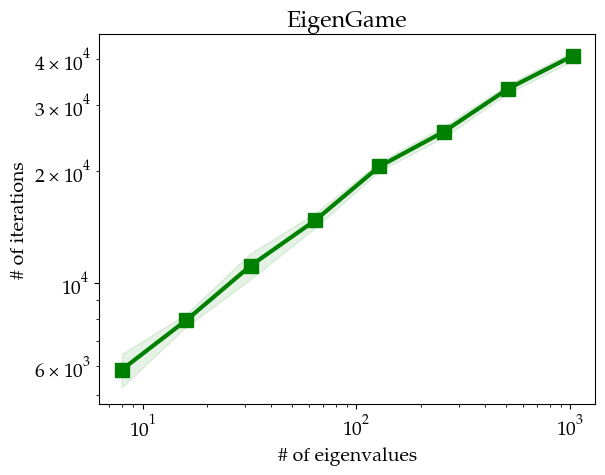

In [ ]:
plt.rcParams["font.family"] = "Palatino"
plt.rcParams["font.size"] = 14
plt.title(r"EigenGame")
plt.xlabel('# of eigenvalues')
plt.ylabel('# of iterations')

markersize = 10
linewidth = 3
attempts = 5
dims = [8, 16, 32, 64, 128, 256, 512, 1024]

total_steps_list = [[sum(steps_list_attempts[i][j]) for j in range(len(steps_list_attempts[i]))] for i in range(len(steps_list_attempts))]
avg_steps_list = [sum([total_steps_list[i][j] for i in range(attempts)]) / attempts for j in range(len(dims))]
std_steps_list = [np.std([total_steps_list[i][j] for i in range(attempts)]) for j in range(len(dims))]
max_steps_list = [avg_steps_list[i] + 1.96*std_steps_list[i] / np.sqrt(attempts) for i in range(len(dims))]
min_steps_list = [avg_steps_list[i] - 1.96*std_steps_list[i] / np.sqrt(attempts) for i in range(len(dims))]

plt.plot(dims, avg_steps_list, marker='s', linewidth=linewidth, markersize=markersize, color='green', label='EigenGame')
plt.fill_between(dims, avg_steps_list, max_steps_list, color='green', alpha=0.1)
plt.fill_between(dims, avg_steps_list, min_steps_list, color='green', alpha=0.1)

plt.xscale('log')
plt.yscale('log')

plt.savefig(current_dir + 'eigengame_only_results.pdf')
plt.savefig(current_dir + 'eigengame_only_results.png')

## Zeroth

### Functions

In [ ]:
def generate_matrix(eigenvalues):
  D = np.diag(eigenvalues)
  P, _ = np.linalg.qr(np.random.rand(len(eigenvalues), len(eigenvalues)))
  return np.dot(P, np.dot(D, np.linalg.inv(P))), P

In [ ]:
def rewards(v_i, M):
  return (jnp.conj(v_i.T) @ M @ v_i).real
  #return jnp.linalg.norm(X @ v_i)**2

def penalties(v_i, M, v=[]):
  return jnp.array([jnp.abs(jnp.conj(v_i.T) @ M @ v_j)**2 / jnp.abs(jnp.conj(v_j.T) @ M @ v_j) for v_j in v]).sum(axis=0)
  #return jnp.array([(jnp.conj(X @ v_i) @ X @ v_j)**2 / (jnp.linalg.norm(X @ v_j))**2 for v_j in v]).sum(axis=0)

@jax.jit
def agent_utility(v_i, M, v=[]):
  return rewards(v_i, M) - penalties(v_i, M, v)

def d_agent_utility_epsilon(v_i, X, v = [], epsilon = 10e-5):
  d = X.shape[0]
  I = jnp.eye(d)*epsilon
  gradient = []
  for m in range(d):
    epsilon_vector = jnp.zeros(d)
    epsilon_vector += I[m]
    v_i_epsilon = v_i + epsilon_vector
    term_0 = agent_utility(v_i_epsilon, X, v)
    term_1 = agent_utility(v_i, X, v)
    term = (term_0 - term_1) / epsilon
    gradient.append(term)
  return jnp.array(gradient)

@jax.jit
def d_agent_utility_R_epsilon(v_i, M, v=[]):
  grad_u_epsilon = d_agent_utility_epsilon(v_i, M, v)

  return grad_u_epsilon - jnp.dot(grad_u_epsilon.T, v_i) * v_i

def eigengame_epsilon(matrix, n_eigs=1, tol=1e-3, optimizer=optax.adam(learning_rate=0.1), max_steps=100, epsilon=1e-5):
  n = matrix.shape[0]

  k = 0
  v_vec = []
  eigenvalues = []

  v = np.random.rand(n)
  v /= np.linalg.norm(v)

  costs_vec = []
  costs = []
  steps = []
  penalties_i = 0
  pbar = tqdm(range(max_steps))
  opt_state = optimizer.init(v)
  for i in pbar:
    grad = d_agent_utility_R_epsilon(v, matrix)
    updates, opt_state = optimizer.update(grad, opt_state, v)
    v = optax.apply_updates(v, -updates)
    cost = rewards(v, matrix)
    costs.append(-cost)
    rewards_i = cost
    pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards_i:.4f}, Penalties: {-penalties_i:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
    if i > 1 and np.linalg.norm(grad) <= tol:
      steps.append(i+1)
      break
  if np.linalg.norm(grad) > tol:
    steps.append(max_steps)
  eigenvalues.append(cost)
  v_vec.append(v)
  costs_vec.append(costs)

  k += 1

  while k < n_eigs:
    v = np.random.rand(n)

    costs = []
    pbar = tqdm(range(max_steps))
    opt_state = optimizer.init(v)
    for i in pbar:
      grad = d_agent_utility_R_epsilon(v, matrix, v_vec)
      updates, opt_state = optimizer.update(grad, opt_state, v)
      v = optax.apply_updates(v, -updates)
      cost = agent_utility(v, matrix, v_vec)
      costs.append(-cost)
      rewards_i = rewards(v, matrix)
      penalties_i = cost - rewards_i
      pbar.set_description(f"Iteration {i + 1}, Cost: {-cost:.4f}, Rewards: {-rewards_i:.4f}, Penalties: {-penalties_i:.4f}, Gradient norm: {np.linalg.norm(grad):.4f}")
      if i > 1 and np.linalg.norm(grad) <= tol:
        steps.append(i+1)
        break
    if np.linalg.norm(grad) > tol:
      steps.append(max_steps)

    eigenvalues.append(cost)
    v_vec.append(v)
    costs_vec.append(costs)
    k += 1

  return eigenvalues, v_vec, costs_vec, steps
  #return cost

### Experiment

Performing experiments for the $0^\text{th}$-order EigenGame and storing the results in a pickle file.

In [ ]:
attempts = 5
dims = [8, 16, 32, 64, 128, 256, 512, 1024]

# Read current state of experiment
#file = open(current_dir + 'zeroth_eigengame.pkl', 'rb')
#data = pickle.load(file)
#file.close()

#zeroth_eigenvalues_list_attempts = data['zeroth_eigenvalues_list_attempts']
#zeroth_v_vec_list_attempts = data['zeroth_v_vec_list_attempts']
#zeroth_costs_vec_list_attempts = data['zeroth_costs_vec_list_attempts']
#zeroth_steps_list_attempts = data['zeroth_steps_list_attempts']

new_attempts = attempts# - len(steps_list_attempts)

# Initialize lists for attempts
zeroth_eigenvalues_list_attempts = []
zeroth_v_vec_list_attempts = []
zeroth_costs_vec_list_attempts = []
zeroth_steps_list_attempts = []

# Run algorithm
for attempt in range(attempts):
  print(f'Attempt {attempt}/{attempts}')

  zeroth_eigenvalues_list = []
  zeroth_v_vec_list = []
  zeroth_costs_vec_list = []
  zeroth_steps_list = []
  for d in dims:
    alpha = 0.5
    eigenvalues = jnp.arange(1, d+1)**(-alpha)
    matrix, P = generate_matrix(eigenvalues)
    print('Real eigenvalues:', eigenvalues)

    schedule = optax.exponential_decay(
      init_value = 0.005,
      transition_steps = 1000,
      decay_rate = 0.90,
      staircase = True
    )

    optimizer = optax.adam(learning_rate=schedule)

    zeroth_eigenvalues, zeroth_v_vec, zeroth_costs_vec, zeroth_steps = eigengame_epsilon(matrix, n_eigs=8, tol=1e-3, optimizer=optimizer, max_steps=50000, epsilon=1e-8)
    print('Calculated eigenvalues:', zeroth_eigenvalues)

    zeroth_eigenvalues_list.append(zeroth_eigenvalues)
    zeroth_v_vec_list.append(zeroth_v_vec)
    zeroth_costs_vec_list.append(zeroth_costs_vec)
    zeroth_steps_list.append(zeroth_steps)

  zeroth_eigenvalues_list_attempts.append(zeroth_eigenvalues_list)
  zeroth_v_vec_list_attempts.append(zeroth_v_vec_list)
  zeroth_costs_vec_list_attempts.append(zeroth_costs_vec_list)
  zeroth_steps_list_attempts.append(zeroth_steps_list)

  # Write current state of experiment
  data = {
    'zeroth_eigenvalues_list_attempts': zeroth_eigenvalues_list_attempts,
    'zeroth_v_vec_list_attempts': zeroth_v_vec_list_attempts,
    'zeroth_costs_vec_list_attempts': zeroth_costs_vec_list_attempts,
    'zeroth_steps_list_attempts': zeroth_steps_list_attempts
  }
  file = open(current_dir + 'zeroth_eigengame.pkl', 'wb')
  pickle.dump(data, file)
  file.close()

Attempt 0/5
Real eigenvalues: [1.         0.70710678 0.57735027 0.5        0.4472136  0.40824829
 0.37796447 0.35355339]


Iteration 161, Cost: -0.9999, Rewards: -0.9999, Penalties: 0.0000, Gradient norm: 0.0009:   0%|          | 160/50000 [00:03<19:00, 43.71it/s]
Iteration 854, Cost: -0.7070, Rewards: -0.7070, Penalties: 0.0000, Gradient norm: 0.0010:   2%|▏         | 853/50000 [00:08<08:20, 98.20it/s] 
Iteration 656, Cost: -0.5773, Rewards: -0.5773, Penalties: 0.0000, Gradient norm: 0.0010:   1%|▏         | 655/50000 [00:06<08:06, 101.41it/s]
Iteration 657, Cost: -0.4999, Rewards: -0.4999, Penalties: 0.0000, Gradient norm: 0.0010:   1%|▏         | 656/50000 [00:06<08:00, 102.79it/s]
Iteration 638, Cost: -0.4472, Rewards: -0.4472, Penalties: 0.0000, Gradient norm: 0.0010:   1%|▏         | 637/50000 [00:06<08:08, 101.04it/s]
Iteration 847, Cost: -0.4081, Rewards: -0.4081, Penalties: 0.0000, Gradient norm: 0.0010:   2%|▏         | 846/50000 [00:08<08:27, 96.84it/s] 
Iteration 1412, Cost: -0.3779, Rewards: -0.3779, Penalties: 0.0000, Gradient norm: 0.0010:   3%|▎         | 1411/50000 [00:14<08:07, 99.74it/s]

Calculated eigenvalues: [Array(0.9998694, dtype=float64), Array(0.70702623, dtype=float64), Array(0.5773201, dtype=float64), Array(0.4999354, dtype=float64), Array(0.44722062, dtype=float64), Array(0.4081372, dtype=float64), Array(0.37789854, dtype=float64), Array(0.35328007, dtype=float64)]
Real eigenvalues: [1.         0.70710678 0.57735027 0.5        0.4472136  0.40824829
 0.37796447 0.35355339 0.33333333 0.31622777 0.30151134 0.28867513
 0.2773501  0.26726124 0.25819889 0.25      ]


Iteration 115, Cost: -0.9999, Rewards: -0.9999, Penalties: 0.0000, Gradient norm: 0.0010:   0%|          | 114/50000 [00:01<11:33, 71.95it/s] 
Iteration 1060, Cost: -0.7070, Rewards: -0.7070, Penalties: 0.0000, Gradient norm: 0.0010:   2%|▏         | 1059/50000 [00:10<08:09, 100.02it/s]
Iteration 1337, Cost: -0.5773, Rewards: -0.5773, Penalties: 0.0000, Gradient norm: 0.0010:   3%|▎         | 1336/50000 [00:13<08:09, 99.43it/s] 
Iteration 940, Cost: -0.5000, Rewards: -0.5000, Penalties: 0.0000, Gradient norm: 0.0010:   2%|▏         | 939/50000 [00:09<08:26, 96.83it/s] 
Iteration 754, Cost: -0.4472, Rewards: -0.4472, Penalties: 0.0000, Gradient norm: 0.0010:   2%|▏         | 753/50000 [00:08<09:00, 91.10it/s] 
Iteration 960, Cost: -0.4082, Rewards: -0.4082, Penalties: 0.0000, Gradient norm: 0.0010:   2%|▏         | 959/50000 [00:10<08:32, 95.69it/s] 
Iteration 964, Cost: -0.3780, Rewards: -0.3780, Penalties: 0.0000, Gradient norm: 0.0010:   2%|▏         | 963/50000 [00:10<09:06, 89.71it

Calculated eigenvalues: [Array(0.99989605, dtype=float64), Array(0.70701184, dtype=float64), Array(0.57733149, dtype=float64), Array(0.4999502, dtype=float64), Array(0.44722978, dtype=float64), Array(0.40823093, dtype=float64), Array(0.37796637, dtype=float64), Array(0.35341883, dtype=float64)]
Real eigenvalues: [1.         0.70710678 0.57735027 0.5        0.4472136  0.40824829
 0.37796447 0.35355339 0.33333333 0.31622777 0.30151134 0.28867513
 0.2773501  0.26726124 0.25819889 0.25       0.24253563 0.23570226
 0.22941573 0.2236068  0.21821789 0.21320072 0.20851441 0.20412415
 0.2        0.19611614 0.19245009 0.18898224 0.18569534 0.18257419
 0.1796053  0.1767767 ]


...

Calculated eigenvalues: [Array(1.00001867, dtype=float64), Array(0.70708696, dtype=float64), Array(0.57732794, dtype=float64), Array(0.50001785, dtype=float64), Array(0.44722767, dtype=float64), Array(0.40824251, dtype=float64), Array(0.37794504, dtype=float64), Array(0.35355694, dtype=float64)]
Real eigenvalues: [1.         0.70710678 0.57735027 0.5        0.4472136  0.40824829
 0.37796447 0.35355339 0.33333333 0.31622777 0.30151134 0.28867513
 0.2773501  0.26726124 0.25819889 0.25       0.24253563 0.23570226
 0.22941573 0.2236068  0.21821789 0.21320072 0.20851441 0.20412415
 0.2        0.19611614 0.19245009 0.18898224 0.18569534 0.18257419
 0.1796053  0.1767767  0.17407766 0.17149859 0.16903085 0.16666667
 0.16439899 0.16222142 0.16012815 0.15811388 0.15617376 0.15430335
 0.15249857 0.15075567 0.1490712  0.14744196 0.14586499 0.14433757
 0.14285714 0.14142136 0.14002801 0.13867505 0.13736056 0.13608276
 0.13483997 0.13363062 0.13245324 0.13130643 0.13018891 0.12909944
 0.12803688 0.1

Iteration 129, Cost: -1.0000, Rewards: -1.0000, Penalties: 0.0000, Gradient norm: 0.0010:   0%|          | 128/50000 [00:01<11:50, 70.16it/s]
Iteration 4265, Cost: -0.7071, Rewards: -0.7071, Penalties: 0.0000, Gradient norm: 0.0010:   9%|▊         | 4264/50000 [01:07<12:02, 63.33it/s]
Iteration 4255, Cost: -0.5773, Rewards: -0.5773, Penalties: 0.0000, Gradient norm: 0.0010:   9%|▊         | 4254/50000 [01:11<12:47, 59.57it/s]
Iteration 4932, Cost: -0.5000, Rewards: -0.5000, Penalties: 0.0000, Gradient norm: 0.0010:  10%|▉         | 4931/50000 [01:25<13:03, 57.50it/s]
Iteration 5672, Cost: -0.4472, Rewards: -0.4472, Penalties: 0.0000, Gradient norm: 0.0010:  11%|█▏        | 5671/50000 [01:50<14:21, 51.44it/s]
Iteration 3783, Cost: -0.4082, Rewards: -0.4082, Penalties: 0.0000, Gradient norm: 0.0010:   8%|▊         | 3782/50000 [01:14<15:10, 50.78it/s]
Iteration 5018, Cost: -0.3780, Rewards: -0.3780, Penalties: 0.0000, Gradient norm: 0.0010:  10%|█         | 5017/50000 [01:40<15:05, 49.67

Calculated eigenvalues: [Array(1.00000225, dtype=float64), Array(0.70710329, dtype=float64), Array(0.57734865, dtype=float64), Array(0.49996724, dtype=float64), Array(0.44719147, dtype=float64), Array(0.40824185, dtype=float64), Array(0.37796878, dtype=float64), Array(0.35354444, dtype=float64)]
Real eigenvalues: [1.         0.70710678 0.57735027 ... 0.03128056 0.03126527 0.03125   ]


Iteration 126, Cost: -1.0000, Rewards: -1.0000, Penalties: 0.0000, Gradient norm: 0.0010:   0%|          | 125/50000 [00:07<46:50, 17.75it/s]
Iteration 6011, Cost: -0.7071, Rewards: -0.7071, Penalties: 0.0000, Gradient norm: 0.0010:  12%|█▏        | 6010/50000 [06:07<44:50, 16.35it/s]
Iteration 5797, Cost: -0.5774, Rewards: -0.5774, Penalties: 0.0000, Gradient norm: 0.0010:  12%|█▏        | 5796/50000 [06:13<47:30, 15.51it/s]
Iteration 5902, Cost: -0.5000, Rewards: -0.5000, Penalties: 0.0000, Gradient norm: 0.0010:  12%|█▏        | 5901/50000 [06:35<49:12, 14.94it/s]
Iteration 6012, Cost: -0.4472, Rewards: -0.4472, Penalties: 0.0000, Gradient norm: 0.0010:  12%|█▏        | 6011/50000 [07:08<52:13, 14.04it/s]
Iteration 7301, Cost: -0.4083, Rewards: -0.4083, Penalties: 0.0000, Gradient norm: 0.0010:  15%|█▍        | 7300/50000 [08:54<52:05, 13.66it/s]
Iteration 6182, Cost: -0.3780, Rewards: -0.3780, Penalties: 0.0000, Gradient norm: 0.0010:  12%|█▏        | 6181/50000 [07:34<53:45, 13.59

Calculated eigenvalues: [Array(1.00000718, dtype=float64), Array(0.70710508, dtype=float64), Array(0.57735397, dtype=float64), Array(0.4999935, dtype=float64), Array(0.44721208, dtype=float64), Array(0.40825753, dtype=float64), Array(0.37796909, dtype=float64), Array(0.3535479, dtype=float64)]


In [ ]:
file = open(current_dir + 'zeroth_eigengame.pkl', 'rb')
data = pickle.load(file)
file.close()

zeroth_eigenvalues_list_attempts = data['zeroth_eigenvalues_list_attempts']
zeroth_v_vec_list_attempts = data['zeroth_v_vec_list_attempts']
zeroth_costs_vec_list_attempts = data['zeroth_costs_vec_list_attempts']
zeroth_steps_list_attempts = data['zeroth_steps_list_attempts']

### Plots

Plotting main classical results for the QuantumGame paper.

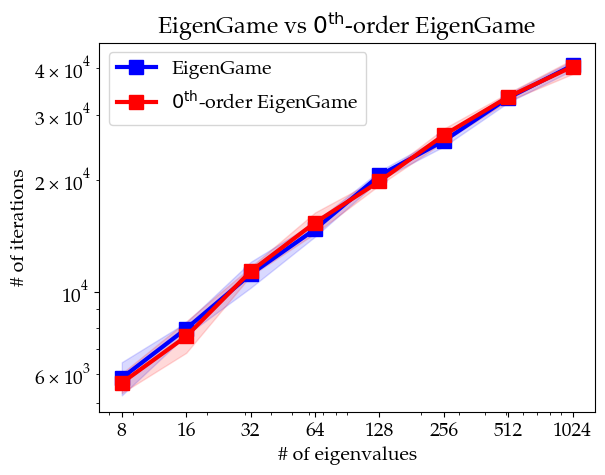

In [ ]:
plt.rcParams["font.family"] = "Palatino"
plt.rcParams["font.size"] = 14
plt.title(r"EigenGame vs $0^\text{th}$-order EigenGame")
plt.xlabel('# of eigenvalues')
plt.ylabel('# of iterations')

markersize = 10
linewidth = 3
attempts = 5

total_steps_list = [[sum(steps_list_attempts[i][j]) for j in range(len(steps_list_attempts[i]))] for i in range(len(steps_list_attempts))]
avg_steps_list = [sum([total_steps_list[i][j] for i in range(attempts)]) / attempts for j in range(len(dims))]
std_steps_list = [np.std([total_steps_list[i][j] for i in range(attempts)]) for j in range(len(dims))]
max_steps_list = [avg_steps_list[i] + 1.96*std_steps_list[i] / np.sqrt(attempts) for i in range(len(dims))]
min_steps_list = [avg_steps_list[i] - 1.96*std_steps_list[i] / np.sqrt(attempts) for i in range(len(dims))]

zeroth_total_steps_list = [[sum(zeroth_steps_list_attempts[i][j]) for j in range(len(zeroth_steps_list_attempts[i]))] for i in range(len(zeroth_steps_list_attempts))]
zeroth_avg_steps_list = [sum([zeroth_total_steps_list[i][j] for i in range(attempts)]) / attempts for j in range(len(dims))]
zeroth_std_steps_list = [np.std([zeroth_total_steps_list[i][j] for i in range(attempts)]) for j in range(len(dims))]
zeroth_max_steps_list = [zeroth_avg_steps_list[i] + 1.96*zeroth_std_steps_list[i] / np.sqrt(attempts) for i in range(len(dims))]
zeroth_min_steps_list = [zeroth_avg_steps_list[i] - 1.96*zeroth_std_steps_list[i] / np.sqrt(attempts) for i in range(len(dims))]

plt.plot(dims, avg_steps_list, marker='s', linewidth=linewidth, markersize=markersize, color='blue', label='EigenGame')
plt.fill_between(dims, avg_steps_list, max_steps_list, color='blue', alpha=0.15)
plt.fill_between(dims, avg_steps_list, min_steps_list, color='blue', alpha=0.15)
plt.plot(dims, zeroth_avg_steps_list, marker='s', linewidth=linewidth, markersize=markersize, color='red', label=r'$0^\text{th}$-order EigenGame')
plt.fill_between(dims, zeroth_avg_steps_list, zeroth_max_steps_list, color='red', alpha=0.15)
plt.fill_between(dims, zeroth_avg_steps_list, zeroth_min_steps_list, color='red', alpha=0.15)
plt.xscale('log')
plt.yscale('log')
plt.xticks(dims, dims)
plt.legend();

plt.savefig(current_dir + 'eigengame_results.pdf', bbox_inches='tight')
plt.savefig(current_dir + 'eigengame_results.png', bbox_inches='tight')